In [3]:
import numpy as np
import networkx as nx
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from src.graphs.utils import *
from src.hyperbolicity.gromov import *
from src.graphs.visualization import *

from collections import Counter
%load_ext autoreload
%autoreload 2
from scipy.stats import wasserstein_distance
from src.optimization.spectral_regularization import *
from src.optimization.solver import *

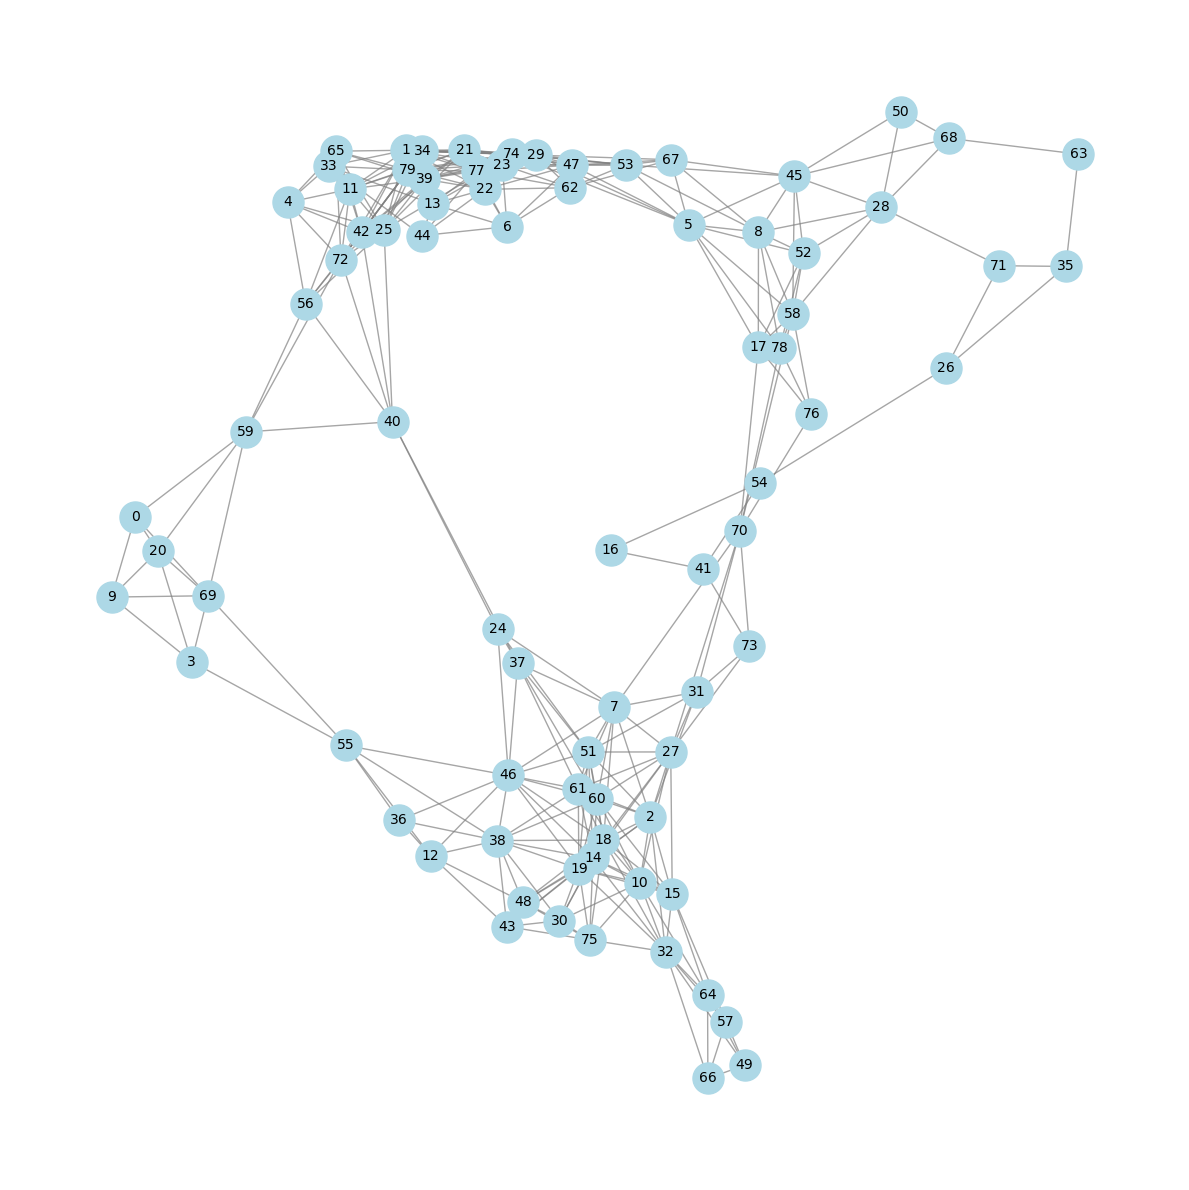

G is connected? True


In [4]:
G = nx.random_geometric_graph(n=80,radius=0.2,dim=2, seed=42)
#G = create_SBM_graph(sizes=[30,30,30], p_intra=[0.1,0.2,0.3], seed = 43)
pos = draw_layout(G)
draw_graphs(G, pos, base_figsize=(12,12))

print(f"G is connected? {nx.is_connected(G)}")
L = nx.normalized_laplacian_matrix(G).toarray()
dist = compute_distance_nodes(G)
N = G.number_of_nodes()
alpha = 1
H = np.linalg.inv(np.eye(N) + alpha *L) 


## observing the differences between intra_distance in the tuple and graph energy diffusion

In [3]:
intra_distance_dict = {}
for x,y,z,w in itertools.combinations(range(N), 4):
    intra_distance_dict[(x,y,z,w)] = compute_intra_distance(dist,(x,y,z,w))

energies = compute_energy(G, alpha=0.5) # energies is a dict -> quad : energy

In [4]:
from scipy.stats import pearsonr
pearsonr(list(intra_distance_dict.values()),list(energies.values()))

PearsonRResult(statistic=np.float64(0.30208594503639685), pvalue=np.float64(0.0))

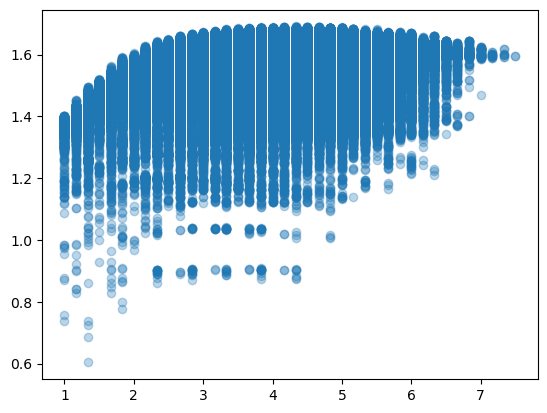

In [7]:
plt.scatter(list(intra_distance_dict.values()),list(energies.values()), alpha=0.3)
plt.show()



In [49]:
intra_distance_dict = dict(sorted(intra_distance_dict.items(), key=lambda x: x[1], reverse=True))
energies = dict(sorted(energies.items(), key=lambda x: x[1], reverse=True))

In [8]:
for i in range(5):
    distant_nodes = list(intra_distance_dict)[i][0]
    close_nodes = list(intra_distance_dict)[-(i+1)][0]
    
    
    y = np.zeros(N)
    y[np.array(distant_nodes)] = 1
    distant_x = H @ y

    y = np.zeros(N)
    y[np.array(close_nodes)] = 1
    close_x = H @ y

    close_L = close_x.T @ L @ close_x
    distant_L = distant_x.T @ L @ distant_x
    print(f"distant : {distant_L}")
    print(f"close: {close_L}")
    if close_L < distant_L:
        print("close wins")
    else:        
        print("distant wins")
    print("-" * 20)

distant : 0.2203490149805786
close: 0.2335099579948326
distant wins
--------------------
distant : 0.2203490149805786
close: 0.23645385247508016
distant wins
--------------------
distant : 0.2203490149805786
close: 0.23645385247508016
distant wins
--------------------
distant : 0.2203490149805786
close: 0.23645385247508016
distant wins
--------------------
distant : 0.2203490149805786
close: 0.23645385247508016
distant wins
--------------------


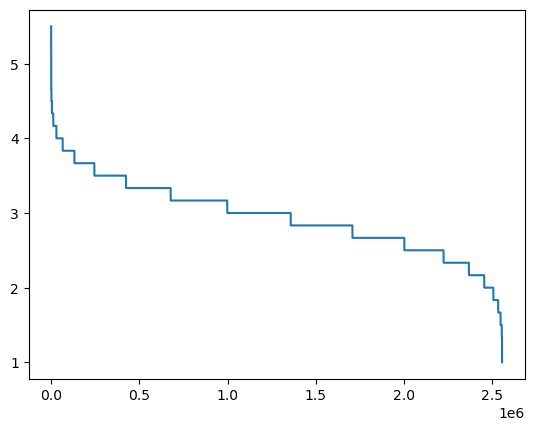

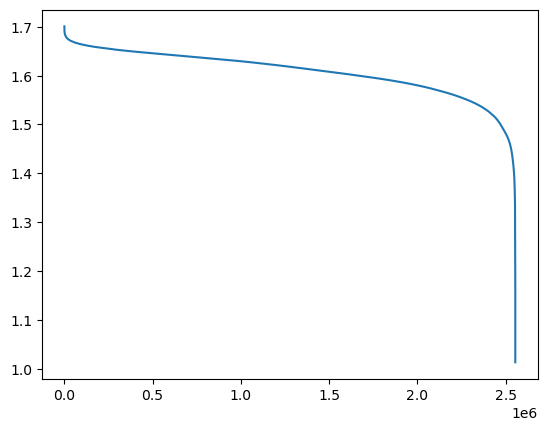

In [51]:
plt.plot(list(intra_distance_dict.values()))
plt.show()
plt.plot(list(energies.values()))

## computing gromov using graph energies as distance function 

In [5]:
delta_max, quads = compute_gromov_hyperbolicity(G)
max_quads = [quad for quad, delta in quads.items() if delta == delta_max]
zero_quads = [quad for quad, delta in quads.items() if delta == 0]
delta_distribution = Counter(quads.values())
print(delta_distribution)

Counter({np.float64(0.0): 766948, np.float64(0.5): 553063, np.float64(1.0): 176001, np.float64(1.5): 66212, np.float64(2.0): 17833, np.float64(2.5): 1478, np.float64(3.0): 45})


In [6]:
mu, quads = max_gromov_entropic_distance_regularized(G, lambda_reg=1, T=1)

# --- Risultati ---
top_idx = np.argsort(mu)[-5:][::-1]
print(f"{len(quads)} combinations.")
print("-" * 30)
for i in top_idx:
    print(f"Tupla: {quads[i]} | Peso mu: {mu[i]:.6f}")

# Verifica la somma
print("-" * 30)
print(f"The sum of mu is {np.sum(mu):.4f}")

print(f"Different values of mu are: {len(set(mu))}")

k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_weights = [mu[i] for i in top_indices]
top_deltas = []
dists = compute_distance_nodes(G)
for quad in top_quads:
    top_deltas.append(compute_delta_gromov(dists,quad))
top_deltas = np.array(top_deltas)
print(top_deltas)

1581580 combinations.
------------------------------
Tupla: (5, 25, 37, 70) | Peso mu: 0.000001
Tupla: (7, 40, 58, 74) | Peso mu: 0.000001
Tupla: (26, 28, 41, 70) | Peso mu: 0.000001
Tupla: (5, 24, 25, 70) | Peso mu: 0.000001
Tupla: (54, 58, 71, 73) | Peso mu: 0.000001
------------------------------
The sum of mu is 1.0000
Different values of mu are: 105
[2.  2.  2.  2.  2.  2.  2.  2.5 2.  2. ]


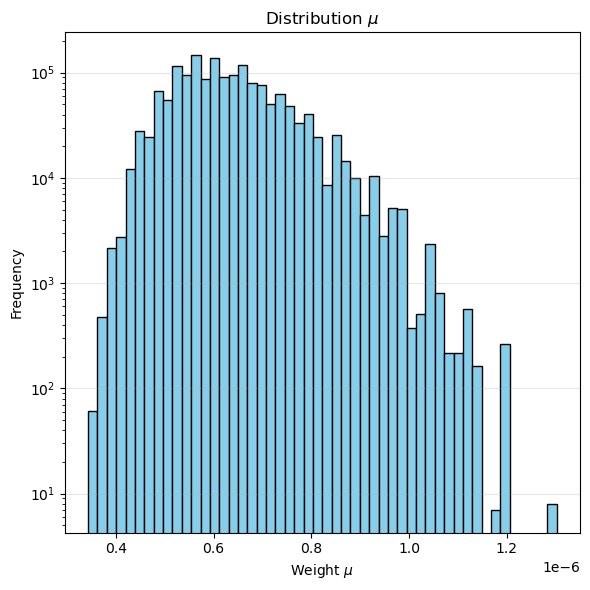

In [7]:
plt.figure(figsize=(6,6))
plt.hist(mu, bins=50, color='skyblue', edgecolor='black', log=True)
plt.title("Distribution $\\mu$")
plt.xlabel("Weight $\\mu$")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Too many quadruples to visualize (10), showing only the first 9.


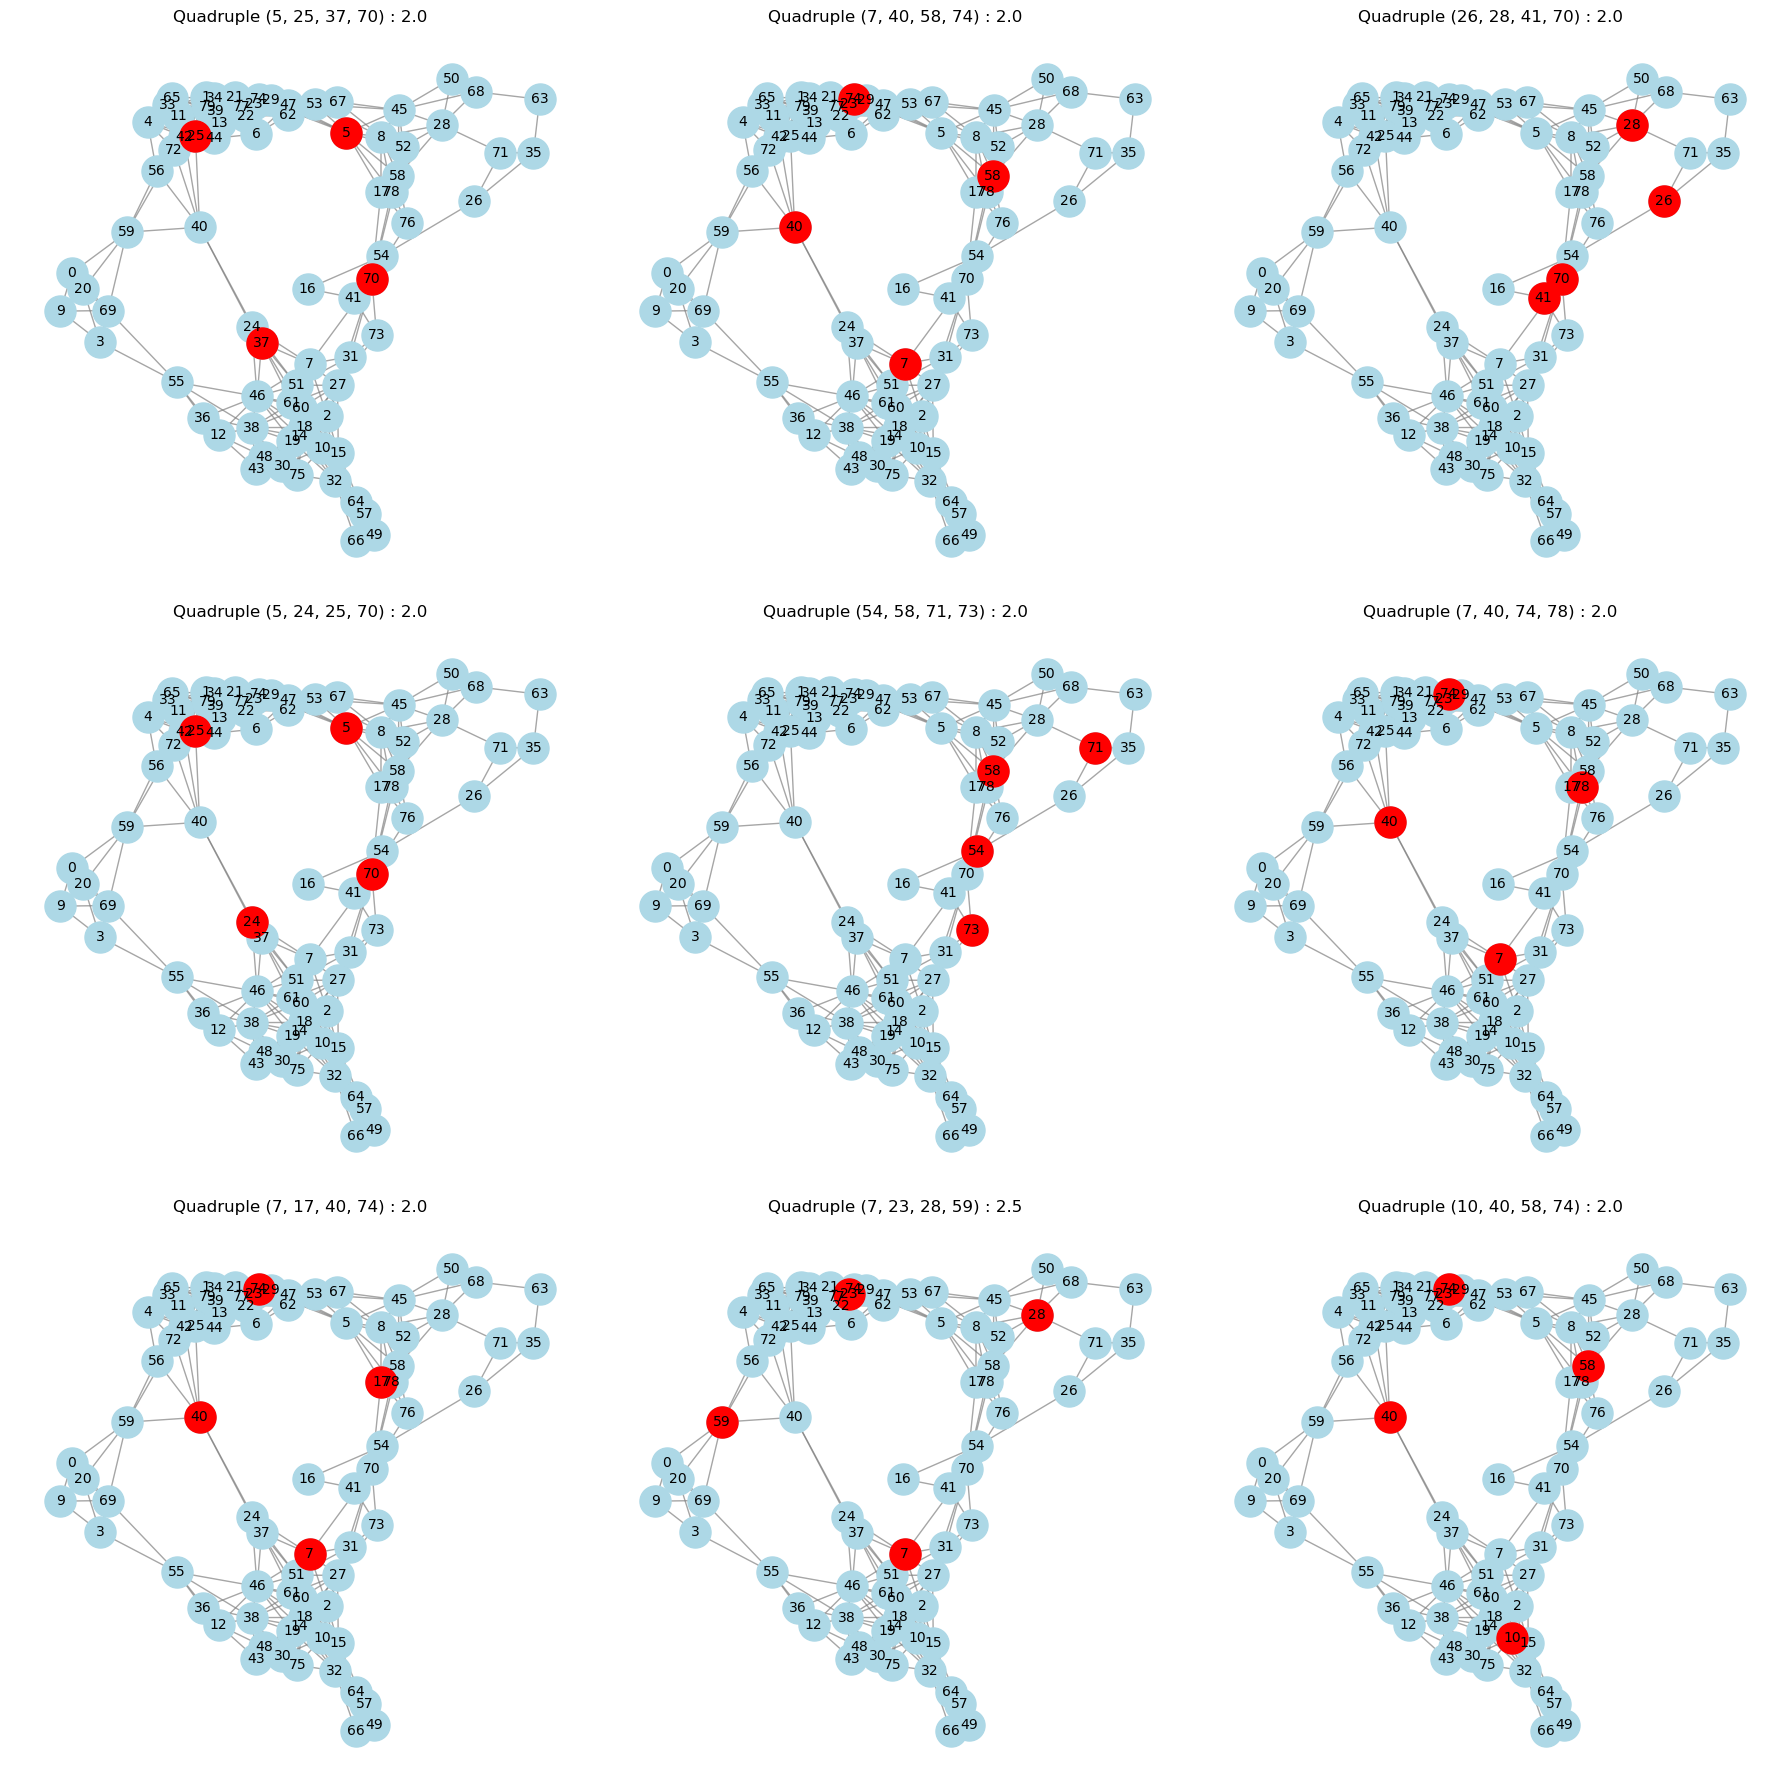

(<Figure size 1800x1800 with 9 Axes>,
 array([<Axes: title={'center': 'Quadruple (5, 25, 37, 70) : 2.0'}>,
        <Axes: title={'center': 'Quadruple (7, 40, 58, 74) : 2.0'}>,
        <Axes: title={'center': 'Quadruple (26, 28, 41, 70) : 2.0'}>,
        <Axes: title={'center': 'Quadruple (5, 24, 25, 70) : 2.0'}>,
        <Axes: title={'center': 'Quadruple (54, 58, 71, 73) : 2.0'}>,
        <Axes: title={'center': 'Quadruple (7, 40, 74, 78) : 2.0'}>,
        <Axes: title={'center': 'Quadruple (7, 17, 40, 74) : 2.0'}>,
        <Axes: title={'center': 'Quadruple (7, 23, 28, 59) : 2.5'}>,
        <Axes: title={'center': 'Quadruple (10, 40, 58, 74) : 2.0'}>],
       dtype=object))

In [68]:
draw_quadruples(G,pos,top_quads, top_deltas)

In [10]:
nodes_list = list(G.nodes())
quadruplets = list(itertools.combinations(nodes_list, 4))
dists = compute_distance_nodes(G)

deltas = []
scores = []

N = len(quadruplets)
x0 = np.full(shape = N, fill_value = 1/N) # uniform distribution

In [14]:
mu, quads = max_gromov_l2_regularization(G, x0, lambda_reg=20, max_steps=30)
# --- Risultati ---
top_idx = np.argsort(mu)[-5:][::-1]
print(f"{len(quads)} combinations.")
print("-" * 30)
for i in top_idx:
    print(f"Tupla: {quads[i]} | Peso mu: {mu[i]:.6f}")

# Verifica la somma
print("-" * 30)
print(f"The sum of mu is {np.sum(mu):.4f}")

print(f"Different values of mu are: {len(set(mu))}")

k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_weights = [mu[i] for i in top_indices]
top_deltas = []
dists = compute_distance_nodes(G)
for quad in top_quads:
    top_deltas.append(compute_delta_gromov(dists,quad))
top_deltas = np.array(top_deltas)
print(top_deltas)

1581580 combinations.
------------------------------
Tupla: (0, 18, 21, 26) | Peso mu: 0.000677
Tupla: (23, 26, 43, 69) | Peso mu: 0.000677
Tupla: (0, 26, 33, 43) | Peso mu: 0.000677
Tupla: (20, 26, 34, 48) | Peso mu: 0.000677
Tupla: (0, 34, 35, 48) | Peso mu: 0.000677
------------------------------
The sum of mu is 1.0000
Different values of mu are: 2
[2.5 2.5 2.5 2.5 2.5 2.5 2.5 2.5 2.5 2.5]


<>:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_15839/1586051503.py:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.title("Distribution $\mu$")
/tmp/ipykernel_15839/1586051503.py:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is 

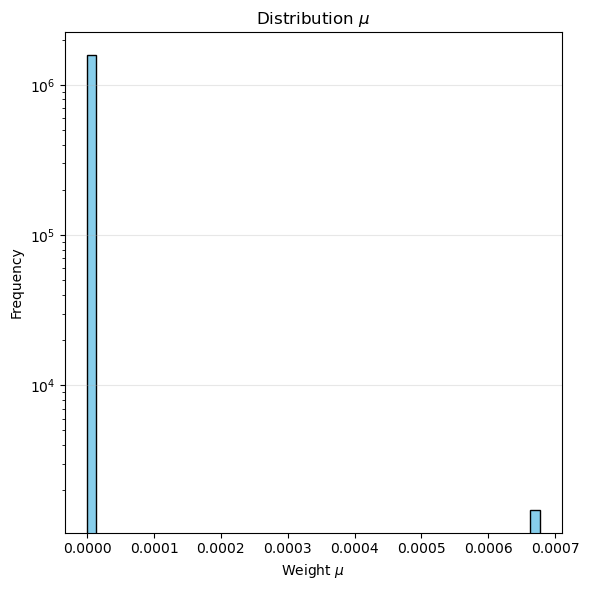

In [16]:
plt.figure(figsize=(6,6))
plt.hist(mu, bins=50, color='skyblue', edgecolor='black', log=True)
plt.title("Distribution $\mu$")
plt.xlabel("Weight $\mu$")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
print(len([q for q in mu if q > 0]))

1478


Too many quadruples to visualize (10), showing only the first 9.


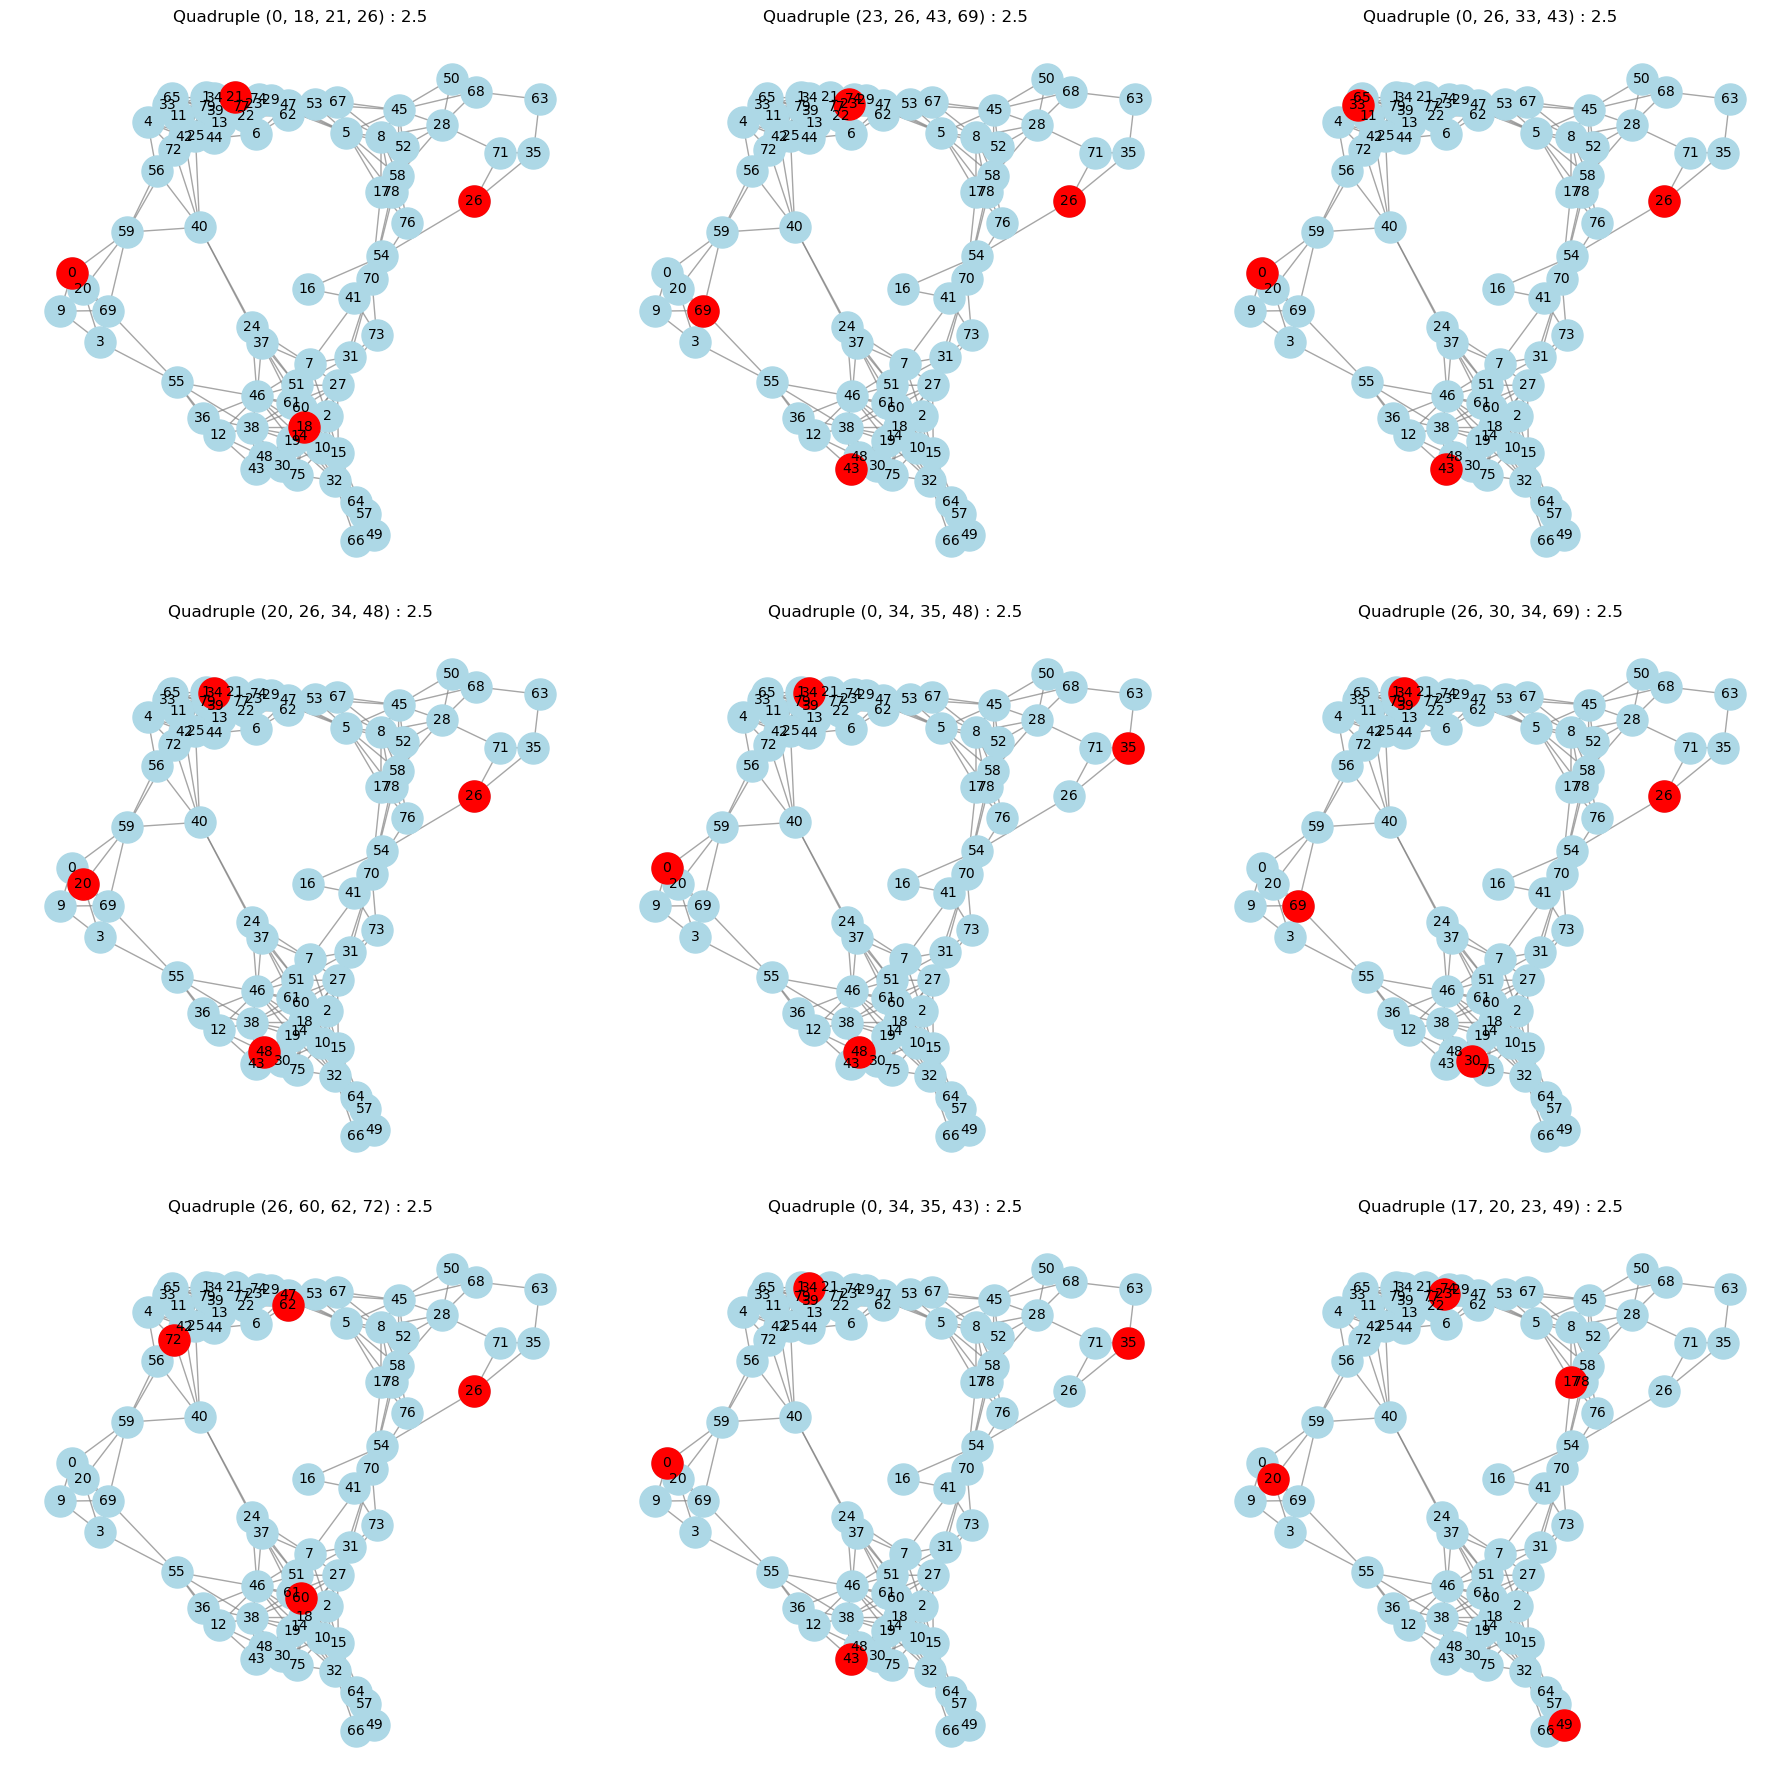

(<Figure size 1800x1800 with 9 Axes>,
 array([<Axes: title={'center': 'Quadruple (0, 18, 21, 26) : 2.5'}>,
        <Axes: title={'center': 'Quadruple (23, 26, 43, 69) : 2.5'}>,
        <Axes: title={'center': 'Quadruple (0, 26, 33, 43) : 2.5'}>,
        <Axes: title={'center': 'Quadruple (20, 26, 34, 48) : 2.5'}>,
        <Axes: title={'center': 'Quadruple (0, 34, 35, 48) : 2.5'}>,
        <Axes: title={'center': 'Quadruple (26, 30, 34, 69) : 2.5'}>,
        <Axes: title={'center': 'Quadruple (26, 60, 62, 72) : 2.5'}>,
        <Axes: title={'center': 'Quadruple (0, 34, 35, 43) : 2.5'}>,
        <Axes: title={'center': 'Quadruple (17, 20, 23, 49) : 2.5'}>],
       dtype=object))

In [107]:
draw_quadruples(G,pos,top_quads, top_deltas)

## graph energy regularization

In [86]:
mu, quads = max_gromov_spectral_regularized(G, lambda_reg=1.2, T=1)

# --- Risultati ---
top_idx = np.argsort(mu)[-5:][::-1]
print(f"{len(quads)} combinations.")
print("-" * 30)
for i in top_idx:
    print(f"Tupla: {quads[i]} | Peso mu: {mu[i]:.6f}")

# Verifica la somma
print("-" * 30)
print(f"The sum of mu is {np.sum(mu):.4f}")

print(f"Different values of mu are: {len(set(mu))}")

k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_weights = [mu[i] for i in top_indices]
top_deltas = []
dists = compute_distance_nodes(G)
for quad in top_quads:
    top_deltas.append(compute_delta_gromov(dists,quad))
top_deltas = np.array(top_deltas)
print(top_deltas)

1581580 combinations.
------------------------------
Tupla: (16, 26, 41, 54) | Peso mu: 0.000002
Tupla: (0, 3, 9, 20) | Peso mu: 0.000002
Tupla: (16, 41, 54, 73) | Peso mu: 0.000002
Tupla: (0, 3, 20, 69) | Peso mu: 0.000001
Tupla: (0, 3, 9, 69) | Peso mu: 0.000001
------------------------------
The sum of mu is 1.0000
Different values of mu are: 1497942
[0.  0.5 0.  0.5 0.5 3.  3.  3.  3.  3. ]


<>:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_4486/1586051503.py:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.title("Distribution $\mu$")
/tmp/ipykernel_4486/1586051503.py:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is al

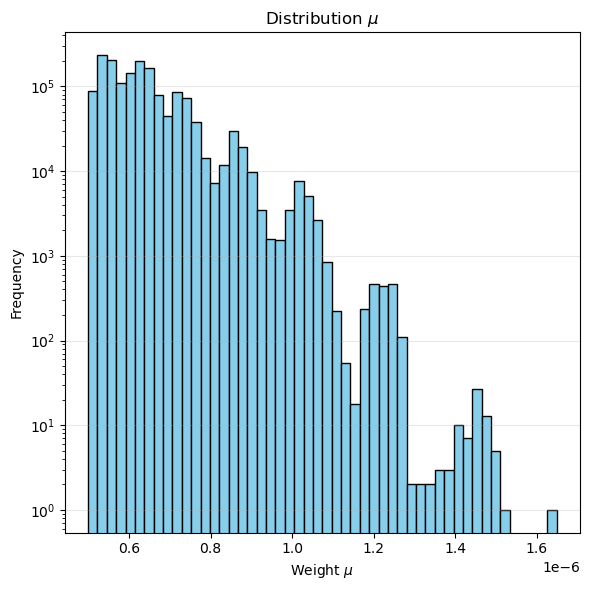

In [87]:
plt.figure(figsize=(6,6))
plt.hist(mu, bins=50, color='skyblue', edgecolor='black', log=True)
plt.title("Distribution $\mu$")
plt.xlabel("Weight $\mu$")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [88]:
max_mu = np.max(mu)
print(len([q for q in mu if q == max_mu]))

1


Too many quadruples to visualize (10), showing only the first 9.


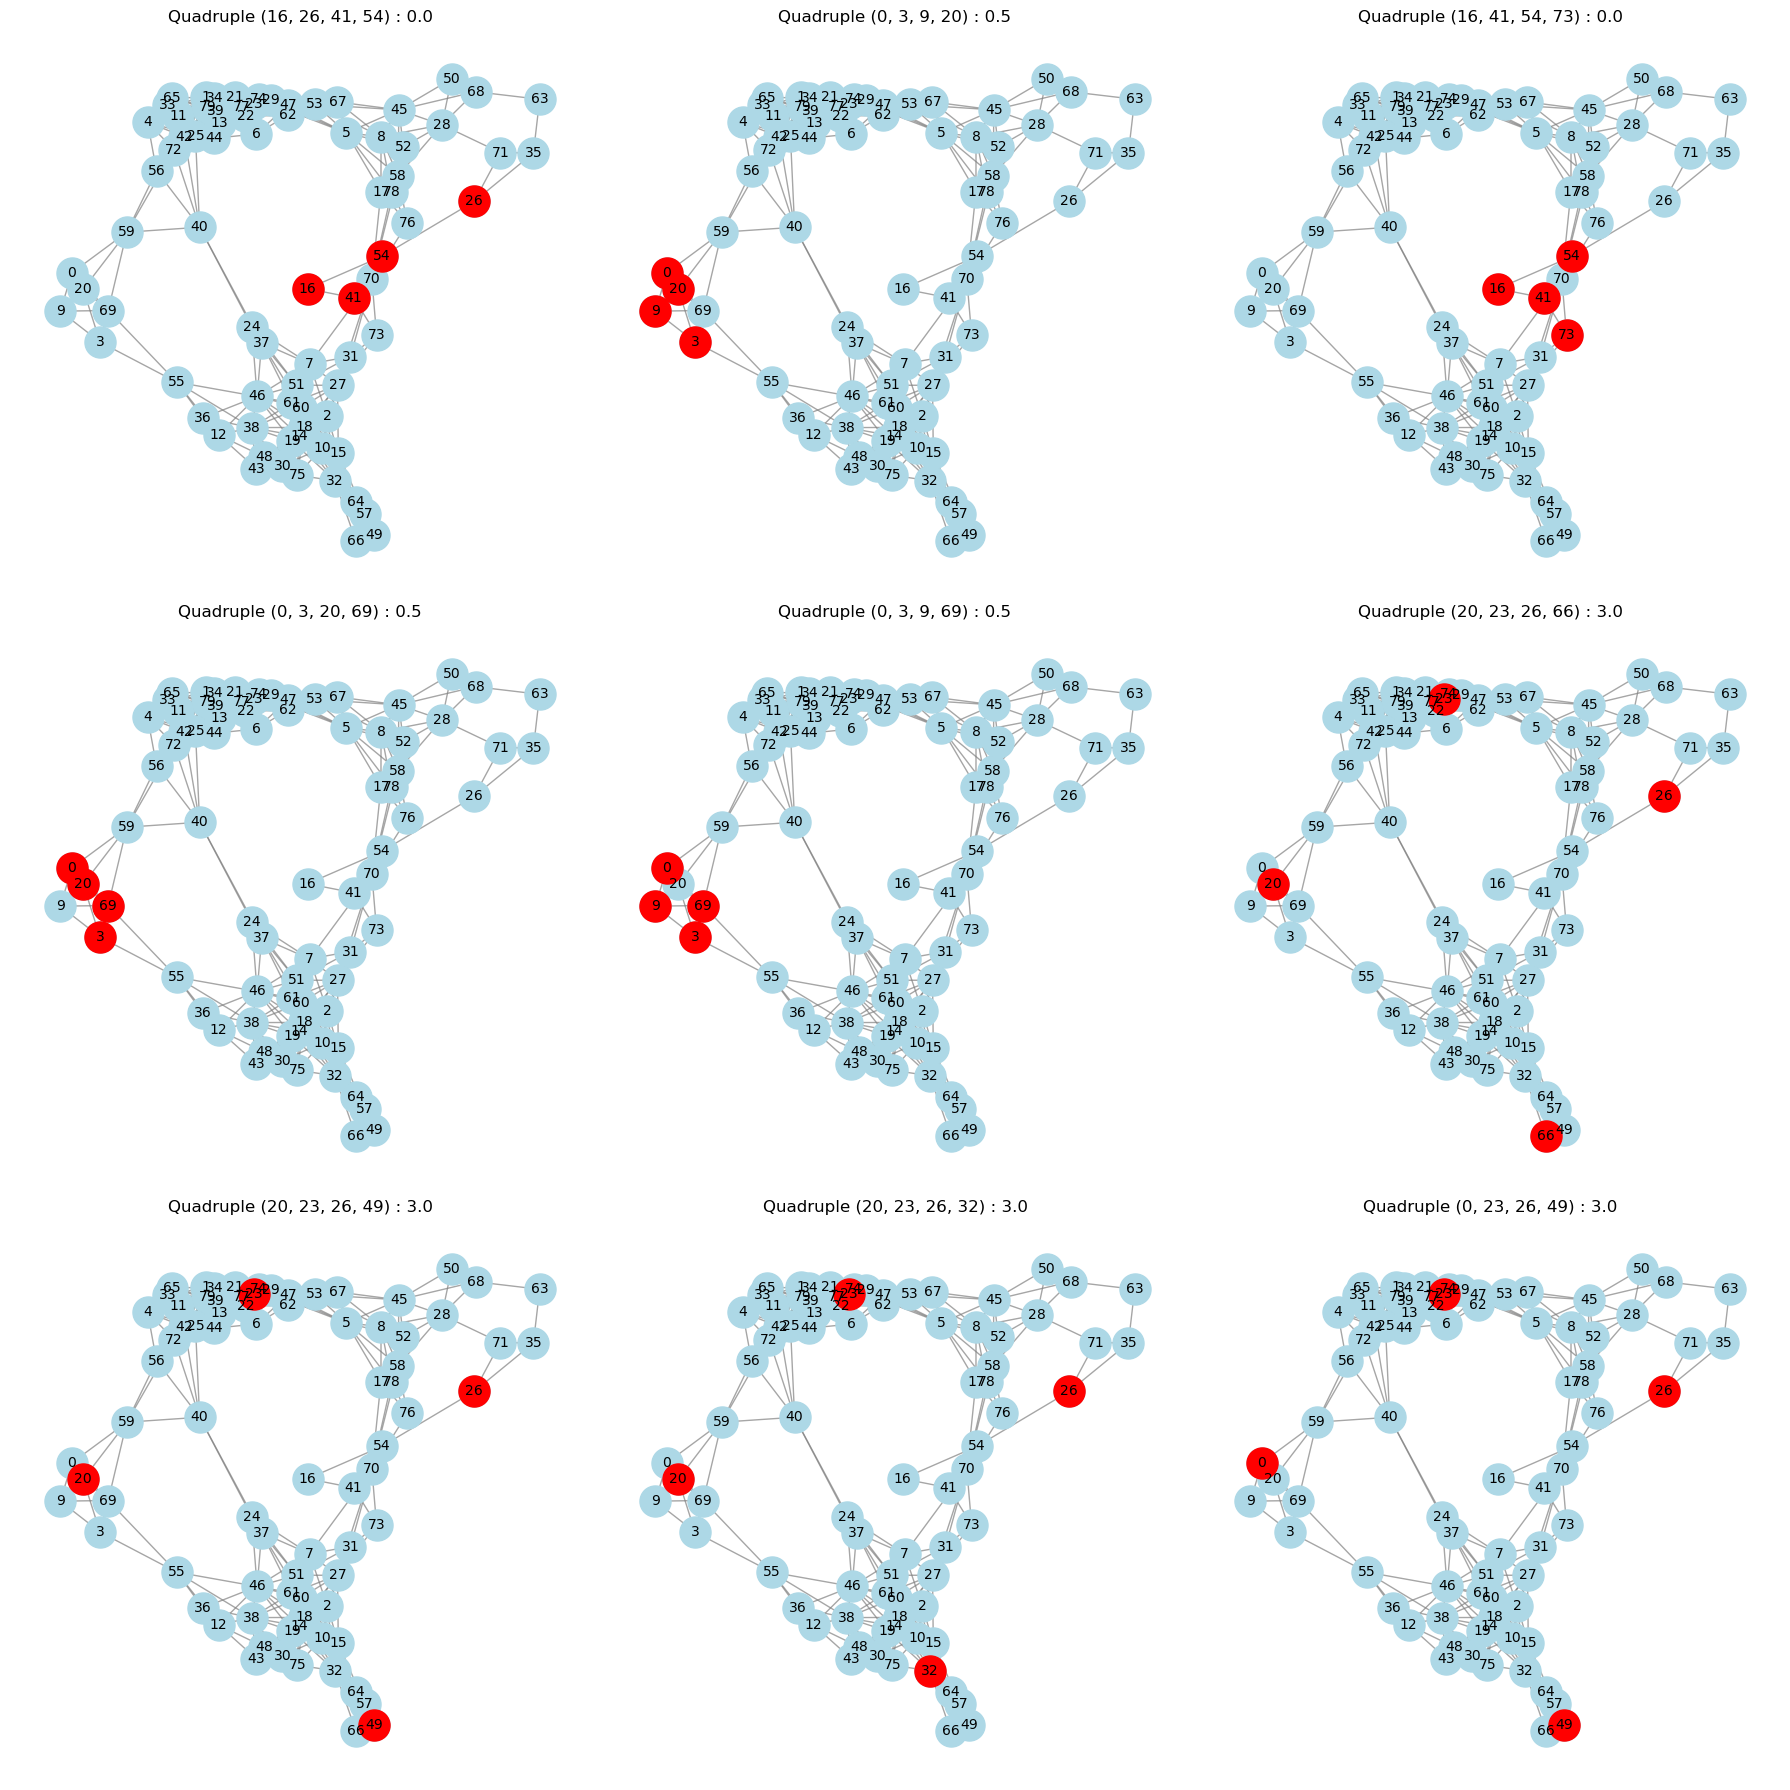

(<Figure size 1800x1800 with 9 Axes>,
 array([<Axes: title={'center': 'Quadruple (16, 26, 41, 54) : 0.0'}>,
        <Axes: title={'center': 'Quadruple (0, 3, 9, 20) : 0.5'}>,
        <Axes: title={'center': 'Quadruple (16, 41, 54, 73) : 0.0'}>,
        <Axes: title={'center': 'Quadruple (0, 3, 20, 69) : 0.5'}>,
        <Axes: title={'center': 'Quadruple (0, 3, 9, 69) : 0.5'}>,
        <Axes: title={'center': 'Quadruple (20, 23, 26, 66) : 3.0'}>,
        <Axes: title={'center': 'Quadruple (20, 23, 26, 49) : 3.0'}>,
        <Axes: title={'center': 'Quadruple (20, 23, 26, 32) : 3.0'}>,
        <Axes: title={'center': 'Quadruple (0, 23, 26, 49) : 3.0'}>],
       dtype=object))

In [90]:
draw_quadruples(G,pos,top_quads, top_deltas)

--------------------

/home/claudio-fantasia/miniconda3/envs/hyperLocal/lib/python3.14/site-packages/networkx/drawing/nx_pylab.py:1497: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


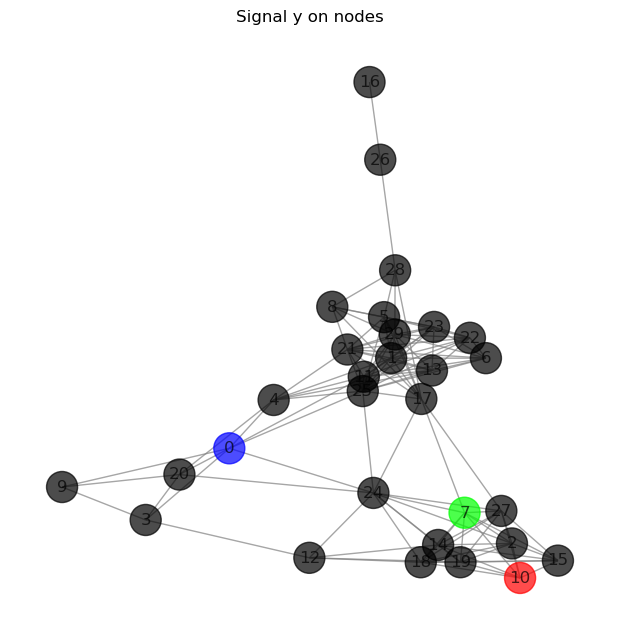

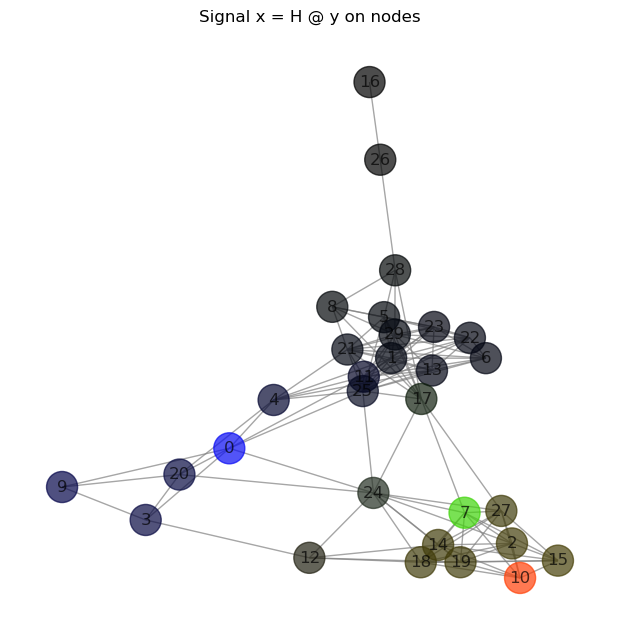

In [44]:
pos = draw_layout(G)

def draw_graph(G, values, title):
    values = np.array(values)

    # normalizzazione per colore (0 -> chiaro, max -> rosso scuro)
    vmin, vmax = values.min(), values.max()
    colors = (values - vmin) / (vmax - vmin)

    plt.figure(figsize=(6,6))

    nx.draw(
        G,
        pos,
        node_color=colors,
        cmap=plt.cm.Reds,
        with_labels=True,
        node_size=500,
        edge_color="gray",
        alpha=0.7
    )

    plt.title(title)
    plt.axis("off")
    plt.show()

# -----------------------
# plot
# -----------------------
draw_graph(G, y, "Signal y on nodes")
draw_graph(G, x, "Signal x = H @ y on nodes")